<a href="https://colab.research.google.com/github/Gunasalini/student-performance-data-science/blob/main/Week_3_Statistical_Analysis_and_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files
uploaded = files.upload()

Saving student+performance.zip to student+performance.zip


In [6]:
import zipfile
import os

with zipfile.ZipFile("student+performance.zip", "r") as zip_ref:
    zip_ref.extractall("student_data")

print(os.listdir("student_data"))
with zipfile.ZipFile("student_data/student.zip", "r") as zip_ref:
    zip_ref.extractall("student_data/extracted")

print(os.listdir("student_data/extracted"))
for root, dirs, files in os.walk("student_data"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

['.student.zip_old', 'student.zip']
['student-por.csv', 'student.txt', 'student-mat.csv', 'student-merge.R']
student_data/extracted/student-por.csv
student_data/extracted/student-mat.csv


In [7]:
mat_df = pd.read_csv(
    "student_data/extracted/student-mat.csv",
    sep=";"
)
por_df = pd.read_csv(
    "student_data/extracted/student-por.csv",
    sep=";"
)
mat_df["subject"] = "Mathematics"
por_df["subject"] = "Portuguese"
df = pd.concat(
    [mat_df, por_df],
    ignore_index=True
)
print("Mathematics records:", len(mat_df))
print("Portuguese records:", len(por_df))
print("Combined records:", len(df))

Mathematics records: 395
Portuguese records: 649
Combined records: 1044


In [8]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (1044, 34)

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'subject']


In [10]:
print(df["studytime"].value_counts().sort_index())
studytime_description = {
    1: "Less than 2 hours",
    2: "2 to 5 hours",
    3: "5 to 10 hours",
    4: "More than 10 hours"
}
for value, description in studytime_description.items():
    print(f"{value} = {description}")

studytime
1    317
2    503
3    162
4     62
Name: count, dtype: int64
1 = Less than 2 hours
2 = 2 to 5 hours
3 = 5 to 10 hours
4 = More than 10 hours


In [11]:
df["study_group"] = np.where(
    df["studytime"].isin([1, 2]),
    "Lower Study Time",
    "Higher Study Time"
)
print(df["study_group"].value_counts())

study_group
Lower Study Time     820
Higher Study Time    224
Name: count, dtype: int64


In [12]:
group_statistics = df.groupby("study_group")["G3"].agg(
    ["count", "mean", "median", "std"]
)

print(group_statistics)

                   count       mean  median       std
study_group                                          
Higher Study Time    224  12.433036    13.0  3.787515
Lower Study Time     820  11.043902    11.0  3.834236


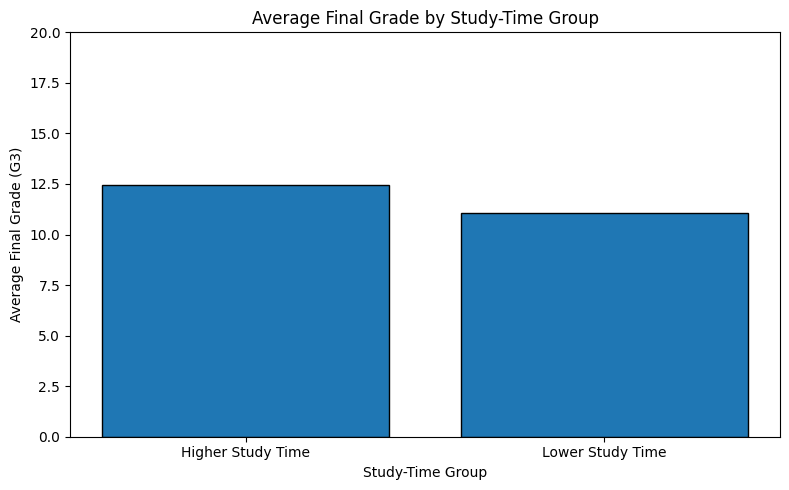

In [13]:
mean_grades = df.groupby("study_group")["G3"].mean()
plt.figure(figsize=(8, 5))
plt.bar(
    mean_grades.index,
    mean_grades.values,
    edgecolor="black"
)
plt.title("Average Final Grade by Study-Time Group")
plt.xlabel("Study-Time Group")
plt.ylabel("Average Final Grade (G3)")
plt.ylim(0, 20)
plt.tight_layout()
plt.show()

/tmp/ipykernel_568/1677083178.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


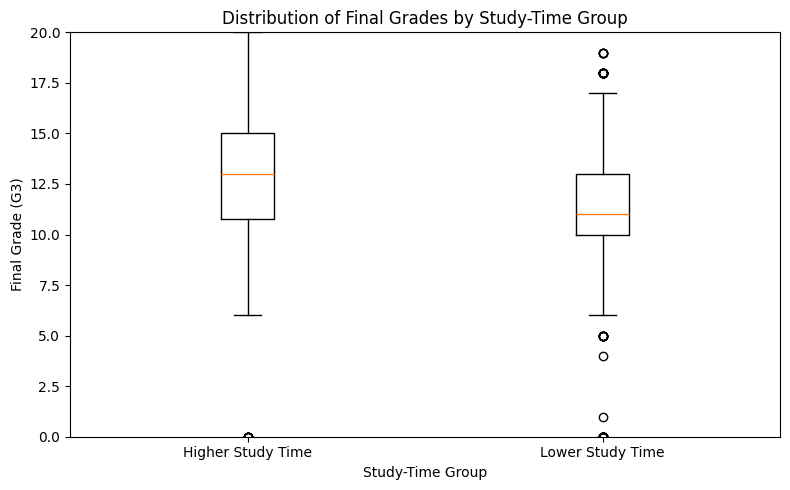

In [14]:
higher_study = df[df["study_group"] == "Higher Study Time"]["G3"]
lower_study = df[df["study_group"] == "Lower Study Time"]["G3"]
plt.figure(figsize=(8, 5))
plt.boxplot(
    [higher_study, lower_study],
    labels=["Higher Study Time", "Lower Study Time"]
)
plt.title("Distribution of Final Grades by Study-Time Group")
plt.xlabel("Study-Time Group")
plt.ylabel("Final Grade (G3)")
plt.ylim(0, 20)
plt.tight_layout()
plt.show()

In [15]:
levene_stat, levene_p = stats.levene(
    higher_study,
    lower_study
)
print("Levene's Test")
print("Statistic:", levene_stat)
print("p-value:", levene_p)

Levene's Test
Statistic: 0.004158892994096451
p-value: 0.9485928530345329


In [16]:
t_stat, p_value = stats.ttest_ind(
    higher_study,
    lower_study,
    equal_var=True
)
print("Independent Samples t-test")
print("t-statistic:", t_stat)
print("p-value:", p_value)

Independent Samples t-test
t-statistic: 4.81808337895902
p-value: 1.664321885765098e-06


In [17]:
mean_difference = higher_study.mean() - lower_study.mean()
n1 = len(higher_study)
n2 = len(lower_study)

pooled_variance = (
    ((n1 - 1) * higher_study.var(ddof=1)) +
    ((n2 - 1) * lower_study.var(ddof=1))
) / (n1 + n2 - 2)

standard_error = np.sqrt(
    pooled_variance * (1/n1 + 1/n2)
)
df_ttest = n1 + n2 - 2
critical_t = stats.t.ppf(
    0.975,
    df_ttest
)
margin_error = critical_t * standard_error

ci_lower = mean_difference - margin_error
ci_upper = mean_difference + margin_error

print("Mean difference:", mean_difference)
print("95% Confidence Interval:")
print("Lower:", ci_lower)
print("Upper:", ci_upper)

Mean difference: 1.3891332752613241
95% Confidence Interval:
Lower: 0.8233860347197416
Upper: 1.9548805158029068


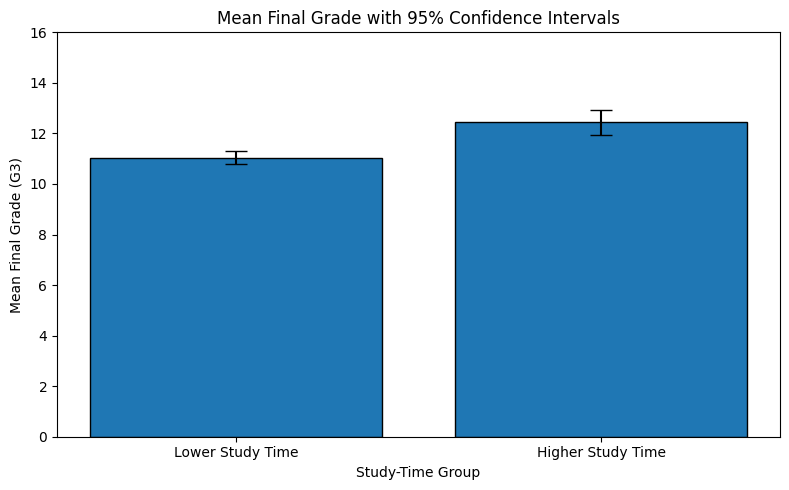

In [18]:
means = [
    lower_study.mean(),
    higher_study.mean()
]
lower_ci = stats.t.interval(
    0.95,
    len(lower_study) - 1,
    loc=lower_study.mean(),
    scale=stats.sem(lower_study)
)

higher_ci = stats.t.interval(
    0.95,
    len(higher_study) - 1,
    loc=higher_study.mean(),
    scale=stats.sem(higher_study)
)

errors = [
    means[0] - lower_ci[0],
    means[1] - higher_ci[0]
]

groups = ["Lower Study Time", "Higher Study Time"]

plt.figure(figsize=(8, 5))

plt.bar(
    groups,
    means,
    yerr=errors,
    capsize=8,
    edgecolor="black"
)

plt.title("Mean Final Grade with 95% Confidence Intervals")
plt.xlabel("Study-Time Group")
plt.ylabel("Mean Final Grade (G3)")
plt.ylim(0, 16)

plt.tight_layout()
plt.show()

In [19]:
n1 = len(higher_study)
n2 = len(lower_study)
pooled_std = np.sqrt(
    (
        (n1 - 1) * higher_study.var(ddof=1)
        + (n2 - 1) * lower_study.var(ddof=1)
    )
    / (n1 + n2 - 2)
)
cohens_d = (
    higher_study.mean() - lower_study.mean()
) / pooled_std
print("Cohen's d:", cohens_d)

Cohen's d: 0.3632399651609561


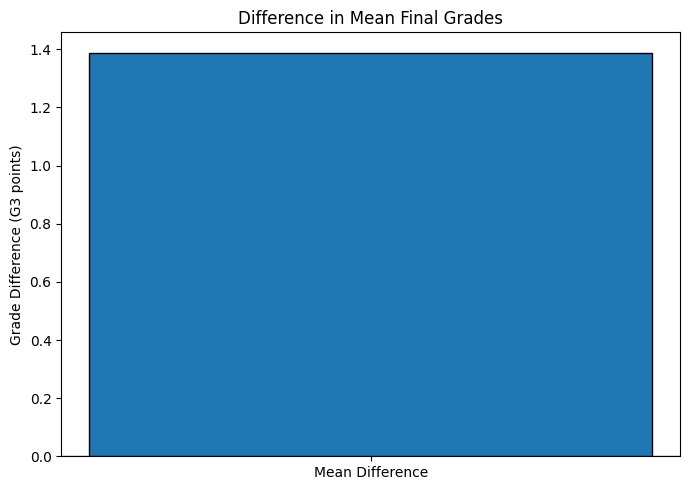

In [20]:
mean_difference = higher_study.mean() - lower_study.mean()
plt.figure(figsize=(7, 5))
plt.bar(
    ["Mean Difference"],
    [mean_difference],
    edgecolor="black"
)
plt.axhline(0, linewidth=1)
plt.title("Difference in Mean Final Grades")
plt.ylabel("Grade Difference (G3 points)")
plt.tight_layout()
plt.show()

# Final Conclusion

## Hypothesis
Students with higher study time have higher final grades.

## Conclusion
The analysis supports the hypothesis. Students in the Higher Study Time group had an average final grade of 12.43, compared with 11.04 for the Lower Study Time group. The mean difference was 1.39 grade points.

Levene's test gave a p-value of 0.949, indicating that the variance between the two groups was not significantly different. The independent samples t-test produced a t-statistic of 4.82 and a p-value of 1.66 × 10⁻⁶. Since the p-value is much smaller than 0.05, the difference in average grades is statistically significant.

The 95% confidence interval for the mean difference was 0.82 to 1.95 grade points, which does not include zero. Cohen's d was 0.36, indicating a small-to-moderate effect.

Overall, the results suggest that students with higher study time tend to achieve higher final grades. However, study time is only one factor affecting academic performance, and other factors may also contribute to students' results.